# Email Spam Classification

## Objective

Build a machine learning model to classify emails as Spam or Ham using natural language processing and machine learning techniques.

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving emails.csv to emails.csv


In [3]:
df = pd.read_csv('emails.csv', encoding='latin-1')

In [4]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
df.shape

(5728, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [7]:
df.duplicated().sum()

np.int64(33)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(5695, 2)

In [10]:
df['spam'].value_counts()

,count
spam,
0,4327
1,1368


In [11]:
df = df.sample(frac=1 , random_state = 2).reset_index(drop=True)
df.shape

(5695, 2)

In [12]:
import nltk

In [29]:
nltk.download('punkt')
nltk.download("punkt_tab")
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
from nltk.tokenize import sent_tokenize

In [15]:
df["char_count"] = df["text"].apply(len)

In [16]:
def count_words(text):
    words = text.split()
    return len(words)

df['word_count'] = df['text'].apply(count_words)

In [22]:
def count_sentences(text):
    return len(sent_tokenize(text))


df['sentence_count'] = df['text'].apply(count_sentences)

In [23]:
df.head()

,text,spam,char_count,word_count,sentence_count
0,Subject: year end 2000 performance feedback n...,0,2170,444,19
1,Subject: clear benefits of creative design lt...,1,1479,328,11
2,Subject: best software prices . big range of ...,1,170,31,4
3,Subject: replacement of stolen chairs hi regg...,0,1175,293,23
4,Subject: returned mail : response error the o...,1,333,80,7


In [24]:
df["sentence_count"]

,sentence_count
0,19
1,11
2,4
3,23
4,7
...,...
5690,15
5691,5
5692,12
5693,3


In [26]:
import re , string

In [27]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [30]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()


In [31]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'^subject:', '', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'<.*?>', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)

    cleaned_words = []

    for word in tokens:

        if word.isalpha() and word not in stop_words:

            cleaned_words.append(stemmer.stem(word))

    return " ".join(cleaned_words)

In [32]:
df['processed_text'] = df['text'].apply(preprocess_text)

In [34]:
df[['text', 'processed_text']].head()

,text,processed_text
0,Subject: year end 2000 performance feedback n...,year end perform feedback note receiv messag t...
1,Subject: clear benefits of creative design lt...,clear benefit creativ design lt realli hard re...
2,Subject: best software prices . big range of ...,best softwar price big rang type download soft...
3,Subject: replacement of stolen chairs hi regg...,replac stolen chair hi reggi spoke regard chai...
4,Subject: returned mail : response error the o...,return mail respons error origin messag receiv...


## Feature Extraction Using TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
tfidf = TfidfVectorizer( max_features=5000 )

In [43]:
X = tfidf.fit_transform(df['processed_text'])

In [44]:
y = df['spam']

In [46]:
print(X.shape)

(5695, 5000)


In [47]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4556
Testing Samples: 1139


In [51]:
from sklearn.naive_bayes import MultinomialNB

In [52]:
model = MultinomialNB()

In [53]:
model.fit(X_train, y_train)

MultinomialNB()

In [55]:
y_pred = model.predict(X_test)

In [58]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

## Model Evaluation

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [61]:
accuracy = accuracy_score(y_test, y_pred)

In [62]:
print("Accuracy:", accuracy)

Accuracy: 0.9806848112379281


In [64]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9806201550387597


In [66]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.937037037037037


In [71]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9583333333333334


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       869
           1       0.98      0.94      0.96       270

    accuracy                           0.98      1139
   macro avg       0.98      0.97      0.97      1139
weighted avg       0.98      0.98      0.98      1139



In [77]:
from sklearn.metrics import confusion_matrix

In [79]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[864,   5],
       [ 17, 253]])

In [80]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9806848112379281
Precision: 0.9806201550387597
Recall: 0.937037037037037
F1 Score: 0.9583333333333334


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

## Spam vs Ham Distribution

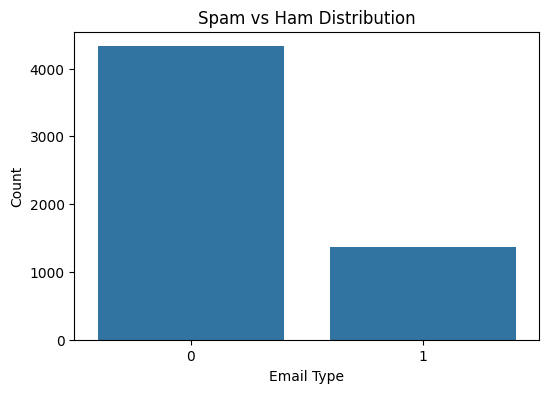

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(x='spam', data=df)

plt.title('Spam vs Ham Distribution')
plt.xlabel('Email Type')
plt.ylabel('Count')

plt.show()

## Confusion Matrix

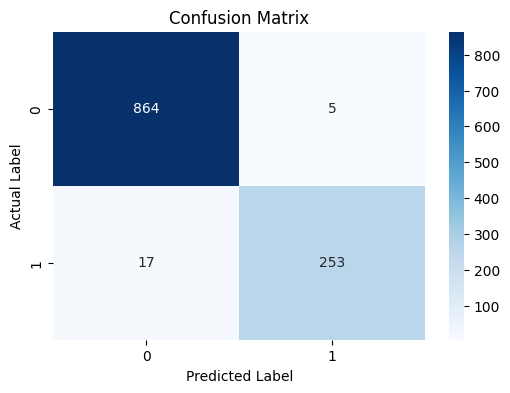

In [83]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

## Custom Email Prediction

In [84]:
def predict_email(email_text):

    processed_email = preprocess_text(email_text)

    vectorized_email = tfidf.transform([processed_email])

    prediction = model.predict(vectorized_email)[0]

    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

In [85]:
sample_email = """
Congratulations!

You have won a $1000 gift card.

Click here to claim your reward now.
"""

predict_email(sample_email)

'Spam'

In [86]:
sample_email2 = """
Hi Team,

The project meeting has been scheduled for tomorrow at 10 AM.

Please review the report before joining.

Regards
"""

predict_email(sample_email2)

'Ham'

## Save Model

In [87]:
import pickle

In [88]:
with open('spam_classifier.pkl', 'wb') as file:
    pickle.dump(model, file)

In [89]:
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

In [90]:
import os

print(os.listdir())


['.config', 'emails.csv', 'tfidf_vectorizer.pkl', 'spam_classifier.pkl', 'sample_data']


In [91]:
with open('spam_classifier.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('tfidf_vectorizer.pkl', 'rb') as file:
    loaded_tfidf = pickle.load(file)